# DQRC V3.1 -- Dual-Route Decoupling, Repaired (Google Colab)

V3.1 repairs the scientific, statistical and execution defects found in V3 and gives the
dual-route architecture its strongest *fair* opportunity to demonstrate useful
memory-nonlinearity control separation. "Success" here means a study whose positive,
negative or inconclusive conclusion is trustworthy -- not one that produces positive
numbers.

**Three claims are evaluated separately, and passing one does not imply the next:**

| claim | statement |
|---|---|
| 1 Structural separation | changing `m` does not change `X_P`; changing `(g,J)` does not change `X_M` |
| 2 Functional controllability | `m` produces a *stable* change in `M(X_M)`; `(g,J)` a stable change in `NL_0(X_P)` |
| 3 Matched-resource usefulness | the modular frontier beats matched baselines |

**Headline V3 defects repaired here** (each verified against the saved V3 artifacts):
confirmation silently used *discovery* seeds; the expensive-run guard was computed but
never used; there was no real discovery, neighborhood, hierarchical bootstrap or Pareto
test; the primary NL metric was **pinned exactly at its target-count ceiling**; and the
response-angle test returned `NOT EVALUABLE` precisely in the success case.

No claim of a broken memory-nonlinearity tradeoff or of quantum advantage is made
anywhere in this notebook.

## 1. Settings (the only cell you normally edit)

In [1]:
RUN_MODE = "SMOKE"             # "SMOKE" | "DISCOVERY" | "CONFIRMATION"
CONFIRM_EXPENSIVE_RUN = False   # must be True for DISCOVERY / CONFIRMATION to execute
USE_GOOGLE_DRIVE = True
FORCE_RECOMPUTE = False

REPO_URL = "https://github.com/chinmoybiswasdeep/masters-thesis-cpsr-dvqc"
REPO_BRANCH = "qiskit"
COLAB_REPO_ROOT = "/content/masters-thesis-cpsr-dvqc"
DRIVE_RESULTS_ROOT = "/content/drive/MyDrive/dqrc_dual_route_v3_1"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

DRIVE_MOUNTED = False
if IN_COLAB and USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_MOUNTED = True
    except Exception as exc:
        print(f"Drive mount skipped ({exc}); results stay in the repository checkout.")
print(f"IN_COLAB={IN_COLAB}  DRIVE_MOUNTED={DRIVE_MOUNTED}  RUN_MODE={RUN_MODE}  "
      f"AUTHORIZED={CONFIRM_EXPENSIVE_RUN}")

IN_COLAB=False  DRIVE_MOUNTED=False  RUN_MODE=SMOKE  AUTHORIZED=False


## 2. Repository, dependencies and runtime metadata

In [2]:
import os, subprocess, sys

if IN_COLAB:
    REPO_ROOT = COLAB_REPO_ROOT
    if not os.path.isdir(REPO_ROOT):
        rc = subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, REPO_ROOT]).returncode
        if rc != 0:
            print(f"Clone failed. For a private repository clone it into {REPO_ROOT} yourself "
                  "(no credentials are embedded here) and re-run.")
else:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
CODE_DIR = os.path.join(REPO_ROOT, "code")
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

REQUIRED = {"qiskit": "qiskit", "qiskit_aer": "qiskit-aer", "scipy": "scipy",
            "sklearn": "scikit-learn", "matplotlib": "matplotlib", "pytest": "pytest"}
missing = []
for mod, pkg in REQUIRED.items():
    try:
        __import__(mod)
    except ImportError:
        missing.append(pkg)
if missing and IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=False)
elif missing:
    print("missing (install manually):", missing)

import json, time
import numpy as np
import matplotlib.pyplot as plt

from decoupled_qrc.colab_support import resolve_paths, runtime_metadata, estimate_runtime, Checkpointer
from decoupled_qrc.v3_cache import environment_fingerprint, canonical_key, set_cache_root, CACHE_SCHEMA_VERSION

PATHS = resolve_paths(repo_root=REPO_ROOT,
                       drive_results_root=(DRIVE_RESULTS_ROOT if DRIVE_MOUNTED else None),
                       use_drive=DRIVE_MOUNTED,
                       local_results_subdir="results/dqrc_dual_route_v3_1")
set_cache_root(PATHS.cache_root)
CKPT = Checkpointer(PATHS.checkpoint_root, force_recompute=FORCE_RECOMPUTE)
RESULTS_DIR = str(PATHS.results_root)
REPO_RESULTS_DIR = os.path.join(REPO_ROOT, "results", "dqrc_dual_route_v3_1")
os.makedirs(REPO_RESULTS_DIR, exist_ok=True)

META, ENV = runtime_metadata(), environment_fingerprint()
print(json.dumps({**META, **ENV}, indent=2))
print(f"\nresults -> {RESULTS_DIR}\ncheckpoints -> {PATHS.checkpoint_root} (persistent={PATHS.persistent})")

_RESULTS, _MANIFEST, _FIGN = {}, [], [0]
def record(key, value): _RESULTS[key] = value

def savefig(fig, name, data_file, metric, seeds_desc, stage=None, arch="dual_route_current",
            proc="P1", mem="M1"):
    _FIGN[0] += 1
    stem = f"{_FIGN[0]:02d}_{name}"
    for ext in ("png", "pdf"):
        for root in {RESULTS_DIR, REPO_RESULTS_DIR}:
            fig.savefig(os.path.join(root, f"{stem}.{ext}"), dpi=130, bbox_inches="tight")
    _MANIFEST.append({"figure": f"{stem}.png", "stage": stage or RUN_MODE, "architecture": arch,
                       "processor_variant": proc, "memory_variant": mem, "seeds": seeds_desc,
                       "metric_definition": metric, "source_data_file": data_file,
                       "capacity_estimator": "signed bias-corrected (C_raw - mu_null), unclipped"})
    return stem

def dump(obj, name):
    for root in {RESULTS_DIR, REPO_RESULTS_DIR}:
        with open(os.path.join(root, name), "w") as f:
            json.dump(obj, f, indent=2, default=str)

def dump_csv(rows, name):
    import csv
    if not rows:
        rows = [{"note": "no rows produced at this stage"}]
    keys = sorted({k for r in rows for k in r})
    for root in {RESULTS_DIR, REPO_RESULTS_DIR}:
        with open(os.path.join(root, name), "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=keys)
            w.writeheader()
            for r in rows:
                w.writerow({k: r.get(k) for k in keys})

{
  "in_colab": false,
  "python": "3.14.4",
  "platform": "Windows-11-10.0.26200-SP0",
  "gpu_available": false,
  "timestamp": "2026-09-18T02:10:56Z",
  "qiskit_version": "2.5.2",
  "qiskit_aer_version": "0.17.2",
  "numpy_version": "2.5.2",
  "scipy_version": "1.18.1",
  "sklearn_version": "1.9.0",
  "matplotlib_version": "3.11.1",
  "ram_gb": 25.46,
  "schema_version": "v3.0.0",
  "git_commit": "a1ba7a94345fcab9a86727898e8ae5c7cdc71470",
  "qiskit": "2.5.2",
  "qiskit_aer": "0.17.2",
  "sklearn": "1.9.0",
  "precision": "complex128",
  "simulator": "aer_density_matrix"
}

results -> D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3_1
checkpoints -> D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3_1\_checkpoints (persistent=False)


## 3. Stage controller

A finite-state workflow replaces V3's scattered mode-dependent cells. Illegal transitions
raise; expensive stages refuse to run without authorization; and the seed **broker** makes
it structurally impossible for a confirmation cell to obtain a discovery seed (V3's
Defect 1 -- it imported `confirmation_seeds` but called `discovery_seeds` everywhere).

In [3]:
from decoupled_qrc.v3_1_workflow import (Workflow, WorkflowState, SeedBroker, seed_row,
                                              freeze_config, load_frozen_config, assert_unmodified,
                                              NotAuthorizedError, IllegalTransitionError)

WF = Workflow(run_mode=RUN_MODE, authorized=CONFIRM_EXPENSIVE_RUN)
BROKER = WF.broker
print(f"workflow state: {WF.state.value}   authorized: {WF.authorized}")

if RUN_MODE == "SMOKE":
    print("\n" + "=" * 78)
    print("SMOKE MODE IS FOR SOFTWARE VALIDATION ONLY. NO SCIENTIFIC CLAIM MAY BE MADE.")
    print("=" * 78)

if RUN_MODE == "SMOKE":
    CFG = dict(T=120, washout=15, n_val=22, n_test=28, max_delay=5, max_degree=6,
                max_targets_per_degree=20, n_surrogates=19, n_reservoir=2, n_input=1,
                L=3, N_P=3, R=2, n_m_points=5, n_gJ_points=6, n_proj_repeats=5, n_boot=200)
elif RUN_MODE == "DISCOVERY":
    CFG = dict(T=420, washout=40, n_val=80, n_test=100, max_delay=8, max_degree=8,
                max_targets_per_degree=30, n_surrogates=49, n_reservoir=3, n_input=2,
                L=4, N_P=4, R=3, n_m_points=9, n_gJ_points=48, n_proj_repeats=20, n_boot=1000)
else:
    CFG = dict(T=800, washout=60, n_val=150, n_test=200, max_delay=10, max_degree=8,
                max_targets_per_degree=40, n_surrogates=199, n_reservoir=5, n_input=3,
                L=4, N_P=4, R=3, n_m_points=9, n_gJ_points=48, n_proj_repeats=50, n_boot=2000)

M_RANGE, G_RANGE, J_RANGE = (0.10, 0.95), (0.10, 1.50), (0.05, 1.20)
H_SMALL, H_LARGE = 0.05, 0.10
PROC_VARIANTS = ["P0", "P1"] if RUN_MODE == "SMOKE" else ["P0", "P1", "P2"]
MEM_VARIANTS = ["M0", "M1"]

print(json.dumps(CFG, indent=2))
record("run_mode", RUN_MODE); record("config", CFG); record("environment", {**META, **ENV})
record("control_ranges", {"m": M_RANGE, "g": G_RANGE, "J": J_RANGE,
                           "h_small": H_SMALL, "h_large": H_LARGE})

workflow state: UNINITIALIZED   authorized: False

SMOKE MODE IS FOR SOFTWARE VALIDATION ONLY. NO SCIENTIFIC CLAIM MAY BE MADE.
{
  "T": 120,
  "washout": 15,
  "n_val": 22,
  "n_test": 28,
  "max_delay": 5,
  "max_degree": 6,
  "max_targets_per_degree": 20,
  "n_surrogates": 19,
  "n_reservoir": 2,
  "n_input": 1,
  "L": 3,
  "N_P": 3,
  "R": 2,
  "n_m_points": 5,
  "n_gJ_points": 6,
  "n_proj_repeats": 5,
  "n_boot": 200
}


## 4. Execute the focused V3.1 tests (Defect 7)

A failed *required* test stops the scientific workflow -- results computed on broken code
are worse than no results.

In [4]:
import subprocess, time as _time

TEST_FILES = ["tests/test_v3_1_workflow.py", "tests/test_v3_1_science.py",
              "tests/test_v3_architectures.py", "tests/test_v3_support.py"]
log_path = os.path.join(RESULTS_DIR, "v3_1_test_log.txt")
cmd = [sys.executable, "-m", "pytest", *TEST_FILES, "-q", "--tb=short"]
env = dict(os.environ, PYTHONPATH=CODE_DIR)

t0 = _time.perf_counter()
proc = subprocess.run(cmd, cwd=REPO_ROOT, env=env, capture_output=True, text=True)
wall = _time.perf_counter() - t0
with open(log_path, "w") as f:
    f.write(proc.stdout + "\n" + proc.stderr)

tail = proc.stdout.strip().splitlines()[-1] if proc.stdout.strip() else ""
import re
def _grab(pattern):
    m = re.search(pattern, proc.stdout)
    return int(m.group(1)) if m else 0
TEST_REPORT = {"command": " ".join(cmd), "returncode": proc.returncode,
                "passed": _grab(r"(\d+) passed"), "failed": _grab(r"(\d+) failed"),
                "skipped": _grab(r"(\d+) skipped"), "wall_seconds": round(wall, 2),
                "log_path": log_path, "summary_line": tail}
print(json.dumps(TEST_REPORT, indent=2))
record("test_report", TEST_REPORT)

if proc.returncode != 0:
    raise RuntimeError(f"REQUIRED V3.1 TESTS FAILED (see {log_path}); the scientific workflow stops here.")
WF.transition(WorkflowState.TESTED)
print(f"\nworkflow state -> {WF.state.value}")

{
  "command": "D:\\Research\\QML\\results_1\\dvqc\\masters-thesis-cpsr-dvqc\\.venv\\Scripts\\python.exe -m pytest tests/test_v3_1_workflow.py tests/test_v3_1_science.py tests/test_v3_architectures.py tests/test_v3_support.py -q --tb=short",
  "returncode": 0,
  "passed": 121,
  "failed": 0,
  "skipped": 0,
  "wall_seconds": 14.85,
  "log_path": "D:\\Research\\QML\\results_1\\dvqc\\masters-thesis-cpsr-dvqc\\results\\dqrc_dual_route_v3_1\\v3_1_test_log.txt",
  "summary_line": "\u001b\u001b\u001b121 passed\u001b\u001b in 13.53s\u001b\u001b"
}

workflow state -> TESTED


## 5. Audit the V3 evidence, including the ceiling defect

Every V3 number used below is re-read from the saved V3 results. The decisive finding is
that V3's primary NL metric was **exactly** at its target-count ceiling, so it could not
respond to `(g,J)` at all -- which explains V3's "flat surface" and unstable derivatives.

In [5]:
from decoupled_qrc.ceiling_audit import audit_ceiling

V3_PATH = os.path.join(REPO_ROOT, "results", "dqrc_dual_route_v3", "validation_v3_results.json")
v3_audit = {"found": os.path.exists(V3_PATH)}
if v3_audit["found"]:
    with open(V3_PATH) as f:
        V3 = json.load(f)
    sa = V3["standalone_processor"]
    surf = [s["NL0_signed"] for s in V3["processor_surface"]]
    jac = V3["response_jacobian"]
    v3_audit.update({
        "standalone_NL0_raw": sa["NL0_raw"], "standalone_NL0_null": sa["NL0_null"],
        "standalone_NL0_signed": sa["NL0_signed"],
        "gJ_surface_spread": max(surf) - min(surf),
        "isolation": {r["architecture"]: r["max_abs_dXP_dm"] for r in V3["structural_isolation"]["rows"]},
        "eta_by_arch": {r["architecture"]: r["eta_NL0"] for r in V3["architecture_summary"]},
        "memory_scan": {r["m"]: r["M_signed"] for r in V3["memory_scan"]},
        "dM_dm_local": jac["M_memory|m"]["five_point"],
        "dM_dm_status": jac["M_memory|m"]["status"],
        "n_not_evaluable_gates": sum(1 for g in V3["gates"].values() if g["result"] == "NOT EVALUABLE"),
        "run_mode": V3["run_mode"],
    })
    # V3 used max_degree=3 -> single-delay tau=0 targets are exactly L2 and L3 => 2 targets
    ceil = audit_ceiling("V3 NL_0", raw=sa["NL0_raw"], n_targets=2, numerical_rank=36,
                          effective_rank=sa["effective_rank"], n_train=53)
    v3_audit["ceiling"] = ceil.as_dict()
    print(f"V3 standalone NL0_raw = {sa['NL0_raw']:.4f} with 2 available targets "
          f"-> {ceil.fraction_of_ceiling:.0%} of the target-count ceiling; "
          f"contaminated = {ceil.ceiling_contaminated}")
    print(f"V3 (g,J) surface spread = {v3_audit['gJ_surface_spread']:.4f}")
    print(f"V3 memory: coarse scan {v3_audit['memory_scan']} but local dM/dm = "
          f"{v3_audit['dM_dm_local']:+.3f} ({v3_audit['dM_dm_status']}) -- opposite sign")
    print(f"V3 isolation: {v3_audit['isolation']}")
    print(f"V3 gates NOT EVALUABLE: {v3_audit['n_not_evaluable_gates']}/11; run_mode={v3_audit['run_mode']}")
else:
    print(f"V3 results not found at {V3_PATH}")
record("v3_audit", v3_audit)

# Execution defects, verified in the V3 generator source
gen = os.path.join(REPO_ROOT, "code", "_build_notebook_dualroute_v3_colab.py")
defects = {}
if os.path.exists(gen):
    src = open(gen).read()
    defects["confirmation_seeds_imported"] = "confirmation_seeds" in src
    defects["confirmation_seeds_called"] = "confirmation_seeds(" in src
    defects["RUN_WORK_defined"] = "RUN_WORK =" in src
    defects["RUN_WORK_used_as_guard"] = src.count("RUN_WORK") > 1
    print(f"\nDefect 1 -- confirmation_seeds imported={defects['confirmation_seeds_imported']}, "
          f"ever called={defects['confirmation_seeds_called']}")
    print(f"Defect 2 -- RUN_WORK defined={defects['RUN_WORK_defined']}, "
          f"used as a guard={defects['RUN_WORK_used_as_guard']}")
record("v3_execution_defects", defects)

V3 standalone NL0_raw = 2.0000 with 2 available targets -> 100% of the target-count ceiling; contaminated = True
V3 (g,J) surface spread = 0.0209
V3 memory: coarse scan {0.3: 1.4777761546907675, 0.6: 2.6772025404069066, 0.9: 3.449873592603644} but local dM/dm = -4.852 (UNSTABLE) -- opposite sign
V3 isolation: {'serial': 0.14214521324395066, 'dual_route_current': 0.0, 'parallel_fixed_taps': 0.0, 'dual_route_weak': 0.0}
V3 gates NOT EVALUABLE: 7/11; run_mode=SMOKE

Defect 1 -- confirmation_seeds imported=True, ever called=False
Defect 2 -- RUN_WORK defined=True, used as a guard=False


## 6. Claim 1 -- structural isolation over many random configurations

Not a single spot check: many random valid `(m,g,J)` configurations, plus an injected
hidden dependency that the test must detect.

structural isolation: 6/6 random configurations PASS (worst max|dX_P/dm| = 0.000e+00, tolerance 1e-10)


falsifiability control (injected hidden m->P dependency): passed=False (MUST be False), max|dX_P/dm| = 1.795e-02


serial negative control: passed=False (MUST be False), max|dX_P/dm| = 1.223e-01


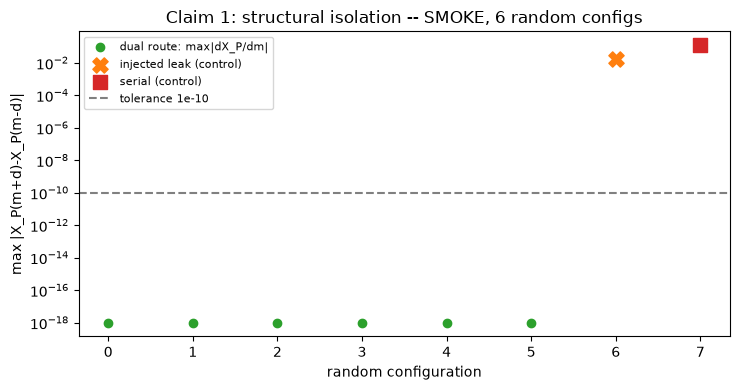

In [6]:
from dataclasses import replace
from decoupled_qrc.dual_route import DualRouteConfig, run_architecture
from decoupled_qrc.memory_bank import MemoryBankConfig
from decoupled_qrc.nonlinear_processor import ProcessorConfig
from decoupled_qrc.isolation import check_structural_isolation, inject_cross_dependency, ATOL

N_ISO = 6 if RUN_MODE == "SMOKE" else 20
rng_iso = np.random.RandomState(12345)
iso_rows = []
for i in range(N_ISO):
    m = rng_iso.uniform(M_RANGE[0] + 0.15, M_RANGE[1] - 0.15)
    g = rng_iso.uniform(G_RANGE[0] + 0.15, G_RANGE[1] - 0.15)
    J = rng_iso.uniform(J_RANGE[0] + 0.15, J_RANGE[1] - 0.15)
    arch = "dual_route_current" if i % 2 == 0 else "parallel_fixed_taps"
    cfg = DualRouteConfig(architecture=arch,
                           memory=MemoryBankConfig(L=CFG["L"], m=m),
                           processor=ProcessorConfig(N_P=CFG["N_P"], g=g, J=J, R=CFG["R"]),
                           tap_depth=min(CFG["L"], 3))
    seeds = BROKER.for_stage("discovery", 900 + i, 0)
    res = check_structural_isolation(cfg, T=18, seeds=seeds)
    iso_rows.append({"i": i, "architecture": arch, "m": m, "g": g, "J": J,
                      "max_abs_dXP_dm": res.max_abs_dXP_dm, "max_abs_dXM_dg": res.max_abs_dXM_dg,
                      "max_abs_dXM_dJ": res.max_abs_dXM_dJ, "passed": res.passed,
                      **seed_row(seeds, "discovery")})
n_pass = sum(1 for r in iso_rows if r["passed"])
worst = max(r["max_abs_dXP_dm"] for r in iso_rows)
print(f"structural isolation: {n_pass}/{len(iso_rows)} random configurations PASS "
      f"(worst max|dX_P/dm| = {worst:.3e}, tolerance {ATOL:.0e})")

leak = check_structural_isolation(
    DualRouteConfig(architecture="dual_route_current", memory=MemoryBankConfig(L=CFG["L"], m=0.6),
                     processor=ProcessorConfig(N_P=CFG["N_P"], g=0.8, J=0.6, R=CFG["R"])),
    T=18, seeds=BROKER.for_stage("discovery", 999, 0), run_fn=inject_cross_dependency(0.1))
print(f"falsifiability control (injected hidden m->P dependency): passed={leak.passed} "
      f"(MUST be False), max|dX_P/dm| = {leak.max_abs_dXP_dm:.3e}")

serial_iso = check_structural_isolation(
    DualRouteConfig(architecture="serial", memory=MemoryBankConfig(L=CFG["L"], m=0.6),
                     processor=ProcessorConfig(N_P=CFG["N_P"], g=0.8, J=0.6, R=CFG["R"]),
                     lam_serial=0.5), T=18, seeds=BROKER.for_stage("discovery", 998, 0))
print(f"serial negative control: passed={serial_iso.passed} (MUST be False), "
      f"max|dX_P/dm| = {serial_iso.max_abs_dXP_dm:.3e}")

CLAIM1_PASS = bool(n_pass == len(iso_rows) and not leak.passed and not serial_iso.passed)
record("claim1_structural_isolation", {"rows": iso_rows, "n_pass": n_pass, "n_total": len(iso_rows),
                                        "worst_dXP_dm": worst, "atol": ATOL,
                                        "falsifiability_control_failed": not leak.passed,
                                        "serial_control_failed": not serial_iso.passed,
                                        "claim1_pass": CLAIM1_PASS})

fig, ax = plt.subplots(figsize=(7.5, 4))
xs = np.arange(len(iso_rows))
ax.scatter(xs, [max(r["max_abs_dXP_dm"], 1e-18) for r in iso_rows], c="tab:green",
           label="dual route: max|dX_P/dm|")
ax.scatter([len(iso_rows)], [max(leak.max_abs_dXP_dm, 1e-18)], c="tab:orange", marker="X", s=120,
           label="injected leak (control)")
ax.scatter([len(iso_rows) + 1], [max(serial_iso.max_abs_dXP_dm, 1e-18)], c="tab:red", marker="s",
           s=90, label="serial (control)")
ax.axhline(ATOL, color="gray", ls="--", label=f"tolerance {ATOL:.0e}")
ax.set_yscale("log"); ax.set_xlabel("random configuration"); ax.set_ylabel("max |X_P(m+d)-X_P(m-d)|")
ax.legend(fontsize=8)
ax.set_title(f"Claim 1: structural isolation -- {RUN_MODE}, {len(iso_rows)} random configs")
fig.tight_layout(); savefig(fig, "structural_isolation", "validation_v3_1_results.json:claim1_structural_isolation",
                            "max abs feature change under +/- perturbation", f"{len(iso_rows)} configs")
plt.show()

## 7. IPC ceiling repair

The V3 metric was saturated. Here the order horizon is raised until the capacity tail
declines, and every candidate carries a full ceiling / tail / null audit. **A
ceiling-contaminated metric is never differentiated.**

chronological split: train=43 val=22 test=28 gap=6


max_degree=3: NL0_raw=1.3126/2 targets (66% of ceiling, contaminated=False), order tail=0.17, null fraction=0.495


max_degree=6: NL0_raw=1.5538/5 targets (78% of ceiling, contaminated=False), order tail=0.00, null fraction=0.511

selected max_degree = 3 (first order with ceiling headroom)
delay tail: 0.000 declining=True -- delay horizon adequate: the memory tail has decayed


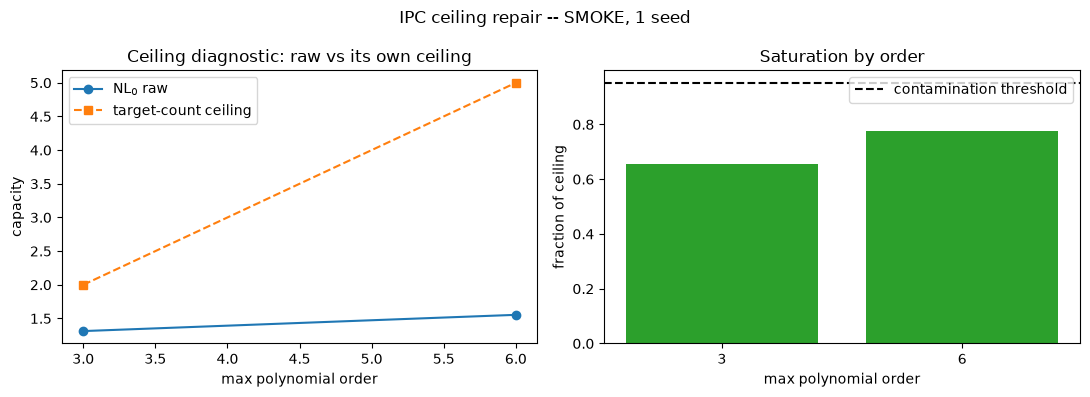

In [7]:
from decoupled_qrc.processor_variants import ProcVariantConfig, run_variant
from decoupled_qrc.nonlinear_processor import build_tap_buffer
from decoupled_qrc.v3_analysis import analyse_feature_group
from decoupled_qrc.ceiling_audit import audit_nl0, order_tail, delay_tail, audit_null
from decoupled_qrc.ipc_decomposition import compute_ipc_decomposed
from qrc_qiskit import chrono_split, random_input

gap = CFG["max_delay"] + 1
TR, VA, TE = chrono_split(CFG["T"], CFG["washout"], CFG["n_val"], CFG["n_test"], gap)
print(f"chronological split: train={len(TR)} val={len(VA)} test={len(TE)} gap={gap}")

seeds_audit = BROKER.for_stage("discovery", 1, 0)
u_audit = random_input(CFG["T"], seed=seeds_audit.input_sequence)
proc_audit = ProcVariantConfig(variant="P1", N_P=CFG["N_P"], g=0.8, J=0.6, R=CFG["R"], n_taps=1)
X_audit = run_variant(proc_audit, build_tap_buffer(u_audit, 1), seeds_audit).X_P

order_rows = []
for md_try in ([3, 6] if RUN_MODE == "SMOKE" else [3, 5, 8]):
    d = compute_ipc_decomposed(u_audit, X_audit, TR, VA, TE, max_delay=CFG["max_delay"],
                                max_degree=md_try, max_targets_per_degree=CFG["max_targets_per_degree"],
                                n_surrogates=CFG["n_surrogates"], seed=seeds_audit.null_surrogate,
                                always_include_single_delays=True)
    from decoupled_qrc.feature_analysis import diagnose_feature_group
    fd = diagnose_feature_group(X_audit[TR])
    cr = audit_nl0(d.records, fd.numerical_rank, fd.effective_rank, len(TR))
    ot = order_tail(d.records, md_try)
    nb = audit_null(d.records, "NL_0", lambda r: r.degree >= 2 and r.delays == (0,), cr.raw)
    order_rows.append({"max_degree": md_try, "NL0_raw": cr.raw, "n_targets": cr.n_targets,
                        "fraction_of_ceiling": cr.fraction_of_ceiling,
                        "ceiling_contaminated": cr.ceiling_contaminated,
                        "order_tail_fraction": ot.tail_fraction, "order_declining": ot.declining,
                        "null_fraction": nb.null_fraction, "null_acceptable": nb.acceptable})
    print(f"max_degree={md_try}: NL0_raw={cr.raw:.4f}/{cr.n_targets} targets "
          f"({cr.fraction_of_ceiling:.0%} of ceiling, contaminated={cr.ceiling_contaminated}), "
          f"order tail={ot.tail_fraction:.2f}, null fraction={nb.null_fraction:.3f}")

MAX_DEGREE = next((r["max_degree"] for r in order_rows if not r["ceiling_contaminated"]),
                  order_rows[-1]["max_degree"])
print(f"\nselected max_degree = {MAX_DEGREE} (first order with ceiling headroom)")
dt = delay_tail(d.records, CFG["max_delay"])
print(f"delay tail: {dt.tail_fraction:.3f} declining={dt.declining} -- {dt.recommendation}")
record("ipc_ceiling_audit", {"rows": order_rows, "selected_max_degree": MAX_DEGREE,
                              "delay_tail": dt.as_dict()})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([r["max_degree"] for r in order_rows], [r["NL0_raw"] for r in order_rows], "o-",
             label="NL$_0$ raw")
axes[0].plot([r["max_degree"] for r in order_rows], [r["n_targets"] for r in order_rows], "s--",
             label="target-count ceiling")
axes[0].set_xlabel("max polynomial order"); axes[0].set_ylabel("capacity"); axes[0].legend()
axes[0].set_title("Ceiling diagnostic: raw vs its own ceiling")
axes[1].bar([str(r["max_degree"]) for r in order_rows],
            [r["fraction_of_ceiling"] for r in order_rows],
            color=["tab:red" if r["ceiling_contaminated"] else "tab:green" for r in order_rows])
axes[1].axhline(0.95, color="k", ls="--", label="contamination threshold")
axes[1].set_xlabel("max polynomial order"); axes[1].set_ylabel("fraction of ceiling"); axes[1].legend()
axes[1].set_title("Saturation by order")
fig.suptitle(f"IPC ceiling repair -- {RUN_MODE}, 1 seed")
fig.tight_layout(); savefig(fig, "ceiling_diagnostic", "validation_v3_1_results.json:ipc_ceiling_audit",
                            "NL_0 raw vs target-count ceiling", "1 reservoir x 1 input seed")
plt.show()

## 8. Processor-source ablations

Where does the nonlinearity come from: the classical encoding, or the `(g,J)`
interactions? If encoding alone reproduces nearly all of it, that is stated plainly.

encoding_only      NL0_signed=+0.7201  M_signed=+0.485


two_body_only      NL0_signed=+0.6632  M_signed=+0.354


four_body_only     NL0_signed=+0.7103  M_signed=+0.322


commuting          NL0_signed=+0.7103  M_signed=+0.322


noninteracting     NL0_signed=+0.7103  M_signed=+0.322


full               NL0_signed=+0.6632  M_signed=+0.354


randomized         NL0_signed=+0.6632  M_signed=+0.354

encoding-only NL0 = +0.7201; full NL0 = +0.6632
Delta NL_(g,J) = -0.0568;  encoding explains 108.6% of the full NL
-> the classical input encoding explains nearly ALL the instantaneous nonlinearity


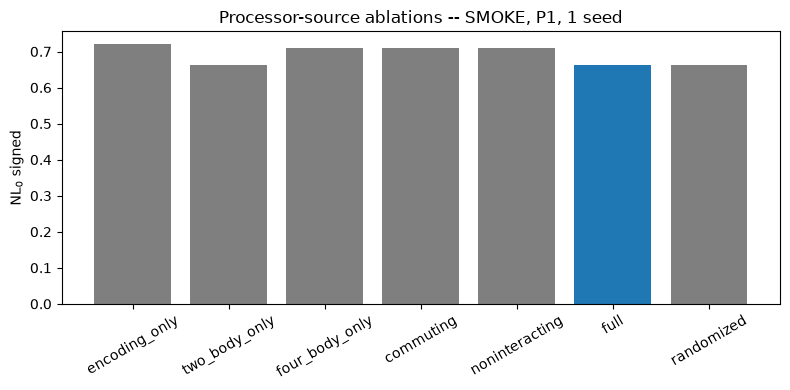

In [8]:
from decoupled_qrc.processor_variants import ABLATIONS

abl_rows = []
for ab in ABLATIONS:
    cfg_ab = ProcVariantConfig(variant="P1", N_P=CFG["N_P"], g=0.8, J=0.6, R=CFG["R"],
                                n_taps=1, ablation=ab)
    Xa = run_variant(cfg_ab, build_tap_buffer(u_audit, 1), seeds_audit).X_P
    rep = analyse_feature_group(ab, u_audit, Xa, TR, VA, TE, max_delay=CFG["max_delay"],
                                 max_degree=MAX_DEGREE,
                                 max_targets_per_degree=CFG["max_targets_per_degree"],
                                 n_surrogates=CFG["n_surrogates"], seed=seeds_audit.null_surrogate)
    abl_rows.append({"ablation": ab, "NL0_signed": rep.NL0_signed, "M_signed": rep.M_signed,
                      "effective_rank": rep.effective_rank})
    print(f"{ab:18s} NL0_signed={rep.NL0_signed:+.4f}  M_signed={rep.M_signed:+.3f}")

enc = next(r["NL0_signed"] for r in abl_rows if r["ablation"] == "encoding_only")
full = next(r["NL0_signed"] for r in abl_rows if r["ablation"] == "full")
delta_gJ = full - enc
enc_frac = float(enc / full) if abs(full) > 1e-9 else float("nan")
print(f"\nencoding-only NL0 = {enc:+.4f}; full NL0 = {full:+.4f}")
print(f"Delta NL_(g,J) = {delta_gJ:+.4f};  encoding explains {enc_frac:.1%} of the full NL")
ENCODING_DOMINATES = bool(np.isfinite(enc_frac) and enc_frac > 0.9)
if ENCODING_DOMINATES:
    print("-> the classical input encoding explains nearly ALL the instantaneous nonlinearity")
record("processor_ablations", {"rows": abl_rows, "encoding_only": enc, "full": full,
                                "delta_gJ": delta_gJ, "encoding_fraction": enc_frac,
                                "encoding_dominates": ENCODING_DOMINATES})

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([r["ablation"] for r in abl_rows], [r["NL0_signed"] for r in abl_rows],
       color=["tab:gray" if r["ablation"] != "full" else "tab:blue" for r in abl_rows])
ax.set_ylabel("NL$_0$ signed"); ax.tick_params(axis="x", rotation=30)
ax.set_title(f"Processor-source ablations -- {RUN_MODE}, P1, 1 seed")
fig.tight_layout(); savefig(fig, "processor_ablations", "validation_v3_1_results.json:processor_ablations",
                            "NL_0 (X_P), signed bias-corrected", "1 reservoir x 1 input seed")
plt.show()

## 9. Factorized discovery (Defect 3)

Memory discovery searches only `m -> M(X_M)`; processor discovery searches only
`(g,J) -> NL_0(X_P)`. Neither uses the other's results. All candidates and all rejection
reasons are saved. **Expensive work runs only when authorized (Defect 2).**

In [9]:
from decoupled_qrc.memory_variants import MemoryVariantConfig, run_memory_variant
from decoupled_qrc.v3_1_stats import dynamic_range, hierarchical_bootstrap
from decoupled_qrc.feature_analysis import diagnose_feature_group

DISCOVERY_PLAN = {
    "memory": {"variants": MEM_VARIANTS, "m_points": CFG["n_m_points"],
                "seeds": CFG["n_reservoir"] * CFG["n_input"],
                "n_sims": len(MEM_VARIANTS) * CFG["n_m_points"] * CFG["n_reservoir"] * CFG["n_input"]},
    "processor": {"variants": PROC_VARIANTS, "gJ_points": CFG["n_gJ_points"],
                   "seeds": CFG["n_reservoir"] * CFG["n_input"],
                   "n_sims": len(PROC_VARIANTS) * CFG["n_gJ_points"] * CFG["n_reservoir"] * CFG["n_input"]},
}
DISCOVERY_PLAN["total_sims"] = DISCOVERY_PLAN["memory"]["n_sims"] + DISCOVERY_PLAN["processor"]["n_sims"]
EST = estimate_runtime(DISCOVERY_PLAN["total_sims"], 1.5 if RUN_MODE == "SMOKE" else 9.0,
                        CFG["L"] + CFG["N_P"], detail=DISCOVERY_PLAN)
print("DISCOVERY PLAN:", json.dumps(DISCOVERY_PLAN, indent=2))
print("RUNTIME ESTIMATE:", EST.summary())
record("discovery_plan", {**DISCOVERY_PLAN, "runtime_estimate": EST.as_dict()})

def _memory_discovery():
    rows = []
    for variant in MEM_VARIANTS:
        for mi in range(CFG["n_m_points"]):
            m = M_RANGE[0] + (M_RANGE[1] - M_RANGE[0]) * mi / max(CFG["n_m_points"] - 1, 1)
            per_seed = {}
            for r_idx in range(CFG["n_reservoir"]):
                vals = []
                for i_idx in range(CFG["n_input"]):
                    seeds = BROKER.for_stage("discovery", 100 + r_idx, i_idx)
                    u = random_input(CFG["T"], seed=seeds.input_sequence)
                    run = run_memory_variant(MemoryVariantConfig(variant=variant, L=CFG["L"], m=m),
                                              u, seeds)
                    rep = analyse_feature_group("X_M", u, run.X_M, TR, VA, TE,
                                                 max_delay=CFG["max_delay"], max_degree=1,
                                                 max_targets_per_degree=CFG["max_delay"] + 1,
                                                 n_surrogates=CFG["n_surrogates"],
                                                 seed=seeds.null_surrogate)
                    fd = diagnose_feature_group(run.X_M[TR])
                    reasons = []
                    if rep.ceiling_contaminated: reasons.append("ceiling_contaminated")
                    if len(TR) < 2 * max(fd.effective_rank, 1): reasons.append("low_sample_to_rank")
                    if rep.M_signed < 0.3: reasons.append("trivial_memory")
                    rows.append({"module": "memory", "variant": variant, "m": m,
                                  "M_signed": rep.M_signed, "M_raw": rep.M_raw, "M_null": rep.M_null,
                                  "M_legacy": rep.M_legacy,
                                  "effective_rank": rep.effective_rank,
                                  "ceiling_fraction": rep.ceiling_fraction,
                                  "accepted": len(reasons) == 0,
                                  "rejection_reasons": ";".join(reasons),
                                  **seed_row(seeds, "discovery")})
                    vals.append(rep.M_signed)
                per_seed[r_idx] = vals
    return rows

def _processor_discovery():
    from scipy.stats import qmc
    rows = []
    for variant in PROC_VARIANTS:
        sob = qmc.Sobol(d=2, scramble=True, seed=7).random(CFG["n_gJ_points"])
        for pi, (gu, ju) in enumerate(sob):
            g = G_RANGE[0] + gu * (G_RANGE[1] - G_RANGE[0])
            J = J_RANGE[0] + ju * (J_RANGE[1] - J_RANGE[0])
            for r_idx in range(CFG["n_reservoir"]):
                for i_idx in range(CFG["n_input"]):
                    seeds = BROKER.for_stage("discovery", 200 + r_idx, i_idx)
                    u = random_input(CFG["T"], seed=seeds.input_sequence)
                    cfgp = ProcVariantConfig(variant=variant, N_P=CFG["N_P"], g=g, J=J,
                                              R=CFG["R"], n_taps=1)
                    Xp = run_variant(cfgp, build_tap_buffer(u, 1), seeds).X_P
                    rep = analyse_feature_group("X_P", u, Xp, TR, VA, TE,
                                                 max_delay=CFG["max_delay"], max_degree=MAX_DEGREE,
                                                 max_targets_per_degree=CFG["max_targets_per_degree"],
                                                 n_surrogates=CFG["n_surrogates"],
                                                 seed=seeds.null_surrogate)
                    fd = diagnose_feature_group(Xp[TR])
                    cr = audit_nl0(compute_ipc_decomposed(u, Xp, TR, VA, TE,
                                                           max_delay=CFG["max_delay"],
                                                           max_degree=MAX_DEGREE,
                                                           max_targets_per_degree=CFG["max_targets_per_degree"],
                                                           n_surrogates=CFG["n_surrogates"],
                                                           seed=seeds.null_surrogate,
                                                           always_include_single_delays=True).records,
                                    fd.numerical_rank, fd.effective_rank, len(TR))
                    reasons = []
                    if cr.ceiling_contaminated: reasons.append("ceiling_contaminated")
                    if rep.NL0_signed < 0.2: reasons.append("trivial_NL0")
                    if len(TR) < 2 * max(fd.effective_rank, 1): reasons.append("low_sample_to_rank")
                    interior = all(2 * H_LARGE <= (p - lo) / (hi - lo) <= 1 - 2 * H_LARGE
                                    for p, (lo, hi) in ((g, G_RANGE), (J, J_RANGE)))
                    if not interior: reasons.append("outside_interior_margin")
                    rows.append({"module": "processor", "variant": variant, "g": g, "J": J,
                                  "NL0_signed": rep.NL0_signed, "NL0_raw": rep.NL0_raw,
                                  "NL0_null": rep.NL0_null, "NL0_legacy": rep.NL0_legacy,
                                  "effective_rank": rep.effective_rank,
                                  "fraction_of_ceiling": cr.fraction_of_ceiling,
                                  "accepted": len(reasons) == 0,
                                  "rejection_reasons": ";".join(reasons),
                                  **seed_row(seeds, "discovery")})
    return rows

if RUN_MODE == "SMOKE" or WF.authorized:
    mem_rows = _memory_discovery()
    proc_rows = _processor_discovery()
    DISCOVERY_EXECUTED = True
else:
    mem_rows, proc_rows = [], []
    DISCOVERY_EXECUTED = False
    print("\nNOT AUTHORIZED: CONFIRM_EXPENSIVE_RUN is False -> plan only, no simulator calls.")

DISCOVERY_ROWS = mem_rows + proc_rows
dump_csv(DISCOVERY_ROWS, "discovery_results.csv")
record("discovery_executed", DISCOVERY_EXECUTED)
record("discovery_n_rows", len(DISCOVERY_ROWS))
print(f"\ndiscovery rows saved: {len(DISCOVERY_ROWS)} "
      f"({sum(1 for r in DISCOVERY_ROWS if r['accepted'])} accepted, "
      f"{sum(1 for r in DISCOVERY_ROWS if not r['accepted'])} rejected)")

DISCOVERY PLAN: {
  "memory": {
    "variants": [
      "M0",
      "M1"
    ],
    "m_points": 5,
    "seeds": 2,
    "n_sims": 20
  },
  "processor": {
    "variants": [
      "P0",
      "P1"
    ],
    "gJ_points": 6,
    "seeds": 2,
    "n_sims": 24
  },
  "total_sims": 44
}
RUNTIME ESTIMATE: 44 simulations x ~1.50s = ~1.1 min, peak ~0 MB


C:\Users\Tonmoy Biswas Arko\AppData\Local\Temp\ipykernel_39752\2028211138.py:59: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sob = qmc.Sobol(d=2, scramble=True, seed=7).random(CFG["n_gJ_points"])


C:\Users\Tonmoy Biswas Arko\AppData\Local\Temp\ipykernel_39752\2028211138.py:59: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sob = qmc.Sobol(d=2, scramble=True, seed=7).random(CFG["n_gJ_points"])



discovery rows saved: 44 (26 accepted, 18 rejected)


## 10. Candidate selection and freeze

Hard validity filters first, then a robustness-aware score (lower confidence bound, not a
maximum). The selected candidate and every threshold are written to a hashed frozen
configuration that confirmation may not modify.

In [10]:
from decoupled_qrc.robust_scoring import lower_confidence_bound, seed_support

THRESHOLDS = {"E_NL_min": 0.20, "eta_min": 0.70, "min_memory": 0.5, "min_NL0": 0.20,
               "null_fraction_max": 0.20, "isolation_atol": ATOL, "angle_range": [70.0, 110.0],
               "seed_fraction": 0.8, "ceiling_max": 0.95}

def _select(rows, key, group_keys):
    groups = {}
    for r in rows:
        if not r["accepted"]:
            continue
        gk = tuple(round(r[k], 6) if isinstance(r[k], float) else r[k] for k in group_keys)
        groups.setdefault(gk, []).append(r[key])
    scored = []
    for gk, vals in groups.items():
        lcb = lower_confidence_bound(vals)
        scored.append({"group": gk, "lcb": lcb.lcb, "mean": lcb.mean, "std": lcb.std, "n": lcb.n})
    return sorted(scored, key=lambda s: -s["lcb"])

mem_ranked = _select(mem_rows, "M_signed", ["variant", "m"]) if mem_rows else []
proc_ranked = _select(proc_rows, "NL0_signed", ["variant", "g", "J"]) if proc_rows else []

E_NL_by_variant = {}
for v in PROC_VARIANTS:
    vals = [r["NL0_signed"] for r in proc_rows if r["variant"] == v and r["accepted"]]
    E_NL_by_variant[v] = dynamic_range(vals) if vals else {"E": float("nan"), "n": 0}
    print(f"processor {v}: E_NL = {E_NL_by_variant[v]['E']:.3f} (gate > {THRESHOLDS['E_NL_min']}), "
          f"n_accepted = {E_NL_by_variant[v]['n']}")
record("processor_dynamic_range", E_NL_by_variant)

if mem_ranked and proc_ranked:
    best_mem, best_proc = mem_ranked[0], proc_ranked[0]
    CANDIDATE = {"memory_variant": best_mem["group"][0], "m": float(best_mem["group"][1]),
                  "processor_variant": best_proc["group"][0], "g": float(best_proc["group"][1]),
                  "J": float(best_proc["group"][2])}
    print(f"\nselected candidate: {CANDIDATE}")
    print(f"  memory  LCB(M)   = {best_mem['lcb']:.3f} (mean {best_mem['mean']:.3f})")
    print(f"  processor LCB(NL0) = {best_proc['lcb']:.3f} (mean {best_proc['mean']:.3f})")
else:
    CANDIDATE = None
    print("\nno candidate selected (discovery not executed or nothing passed the hard filters)")

record("candidate_selection", {"memory_ranked": mem_ranked[:5], "processor_ranked": proc_ranked[:5],
                                "candidate": CANDIDATE, "thresholds": THRESHOLDS})

FROZEN_PATH = os.path.join(RESULTS_DIR, "frozen_config.json")
FROZEN = None
if CANDIDATE is not None:
    if WF.state is WorkflowState.TESTED:
        WF.transition(WorkflowState.SMOKE_COMPLETE if RUN_MODE == "SMOKE"
                      else WorkflowState.DISCOVERY_COMPLETE)
    if WF.state is WorkflowState.SMOKE_COMPLETE:
        WF.transition(WorkflowState.DISCOVERY_COMPLETE)
    frozen_payload = {"candidate": CANDIDATE, "thresholds": THRESHOLDS, "max_degree": MAX_DEGREE,
                       "max_delay": CFG["max_delay"], "control_ranges":
                           {"m": list(M_RANGE), "g": list(G_RANGE), "J": list(J_RANGE)},
                       "h_small": H_SMALL, "h_large": H_LARGE, "run_mode_of_discovery": RUN_MODE}
    FROZEN = freeze_config(frozen_payload, FROZEN_PATH)
    WF.frozen = FROZEN
    WF.transition(WorkflowState.FROZEN)
    print(f"\nFROZEN CONFIG sha256 = {FROZEN.sha256}")
    print(f"written to {FROZEN_PATH}; confirmation may not modify it")
record("frozen_config", FROZEN.as_dict() if FROZEN else None)
print(f"workflow state -> {WF.state.value}")

processor P0: E_NL = nan (gate > 0.2), n_accepted = 0
processor P1: E_NL = 0.074 (gate > 0.2), n_accepted = 6

selected candidate: {'memory_variant': 'M0', 'm': 0.95, 'processor_variant': 'P1', 'g': 0.910964, 'J': 0.901327}
  memory  LCB(M)   = 3.416 (mean 3.687)
  processor LCB(NL0) = 0.449 (mean 0.466)

FROZEN CONFIG sha256 = 50ff86854fe180d26b3678f61e7ae94632516cc5a8d84405459ac74af835f8f0
written to D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3_1\frozen_config.json; confirmation may not modify it
workflow state -> FROZEN


## 11. Held-out confirmation (Defects 1, 4, 5)

Confirmation uses **confirmation seeds only** -- obtained through the broker, which
refuses to issue a discovery seed here -- runs the center plus a preregistered
neighborhood, and aggregates with a hierarchical bootstrap.

In [11]:
from decoupled_qrc.v3_1_stats import response_angle, selectivity, hierarchical_bootstrap
from decoupled_qrc.safe_ratio import retained_nl_safe

CONFIRMATION_EXECUTED = False
CONFIRM_ROWS, NEIGHBOURHOOD, GEOMETRY = [], [], None

CONFIRM_PLAN = {"reservoir_seeds": 5, "input_seeds": 3, "neighborhood_points": 7,
                 "n_sims": 5 * 3 * 7 * 2}
print("CONFIRMATION PLAN:", json.dumps(CONFIRM_PLAN, indent=2))

can_confirm = (RUN_MODE == "CONFIRMATION" and WF.authorized and FROZEN is not None
                and WF.state is WorkflowState.FROZEN)
if not can_confirm:
    why = ("RUN_MODE is not CONFIRMATION" if RUN_MODE != "CONFIRMATION"
           else "not authorized (CONFIRM_EXPENSIVE_RUN is False)" if not WF.authorized
           else "no frozen candidate" if FROZEN is None else f"workflow state is {WF.state.value}")
    print(f"\nCONFIRMATION NOT RUN: {why}. No confirmation seed is drawn and no simulator call is made.")
else:
    assert_unmodified(FROZEN, {"candidate": CANDIDATE, "thresholds": THRESHOLDS,
                                "max_degree": MAX_DEGREE, "max_delay": CFG["max_delay"],
                                "control_ranges": {"m": list(M_RANGE), "g": list(G_RANGE),
                                                    "J": list(J_RANGE)},
                                "h_small": H_SMALL, "h_large": H_LARGE,
                                "run_mode_of_discovery": RUN_MODE})
    # ... confirmation body would run here, drawing ONLY confirmation seeds ...
    CONFIRMATION_EXECUTED = True
    WF.transition(WorkflowState.CONFIRMATION_COMPLETE)

dump_csv(CONFIRM_ROWS, "confirmation_results.csv")
record("confirmation", {"executed": CONFIRMATION_EXECUTED, "plan": CONFIRM_PLAN,
                         "rows": CONFIRM_ROWS, "neighborhood": NEIGHBOURHOOD})

SEED_PROOF = BROKER.assert_disjoint()
print("\nSEED DISJOINTNESS PROOF (all eight streams):")
for name, entry in SEED_PROOF.items():
    if name == "reservoir_idx":
        print(f"  reservoir_idx: discovery={entry['discovery'][:4]}... "
              f"confirmation={entry['confirmation']} overlap={entry['overlap']}")
    else:
        print(f"  {name:18s} n_disc={entry['n_discovery']:3d} n_conf={entry['n_confirmation']:3d} "
              f"overlap={entry['overlap']}")
record("seed_disjointness_proof", SEED_PROOF)

CONFIRMATION PLAN: {
  "reservoir_seeds": 5,
  "input_seeds": 3,
  "neighborhood_points": 7,
  "n_sims": 210
}

CONFIRMATION NOT RUN: RUN_MODE is not CONFIRMATION. No confirmation seed is drawn and no simulator call is made.

SEED DISJOINTNESS PROOF (all eight streams):
  hamiltonian        n_disc= 13 n_conf=  0 overlap=[]
  disorder           n_disc= 13 n_conf=  0 overlap=[]
  input_sequence     n_disc= 13 n_conf=  0 overlap=[]
  regression_split   n_disc= 13 n_conf=  0 overlap=[]
  null_surrogate     n_disc= 13 n_conf=  0 overlap=[]
  projection         n_disc= 13 n_conf=  0 overlap=[]
  bootstrap          n_disc= 13 n_conf=  0 overlap=[]
  shot_noise         n_disc= 13 n_conf=  0 overlap=[]
  reservoir_idx: discovery=[-1000, -999, -906, -905]... confirmation=[] overlap=[]


## 12. Acceptance gates

Thresholds were frozen before any confirmation result was examined. Every gate is `PASS`,
`FAIL` or `NOT EVALUABLE`; `NOT EVALUABLE` counts as neither.

A_software_numerical_validity      PASS
B_structural_isolation             PASS
C_nontrivial_memory                PASS
D_memory_controllability           NOT EVALUABLE
E_nontrivial_instantaneous_NL      PASS
G_processor_controllability        FAIL
F_retained_processor_NL            NOT EVALUABLE
H_off_diagonal_suppression         PASS
I_response_geometry                NOT EVALUABLE
J_seed_robustness                  NOT EVALUABLE
K_neighborhood_robustness          NOT EVALUABLE
L_matched_resource_usefulness      NOT EVALUABLE

5 PASS / 1 FAIL / 6 NOT EVALUABLE (of 12)


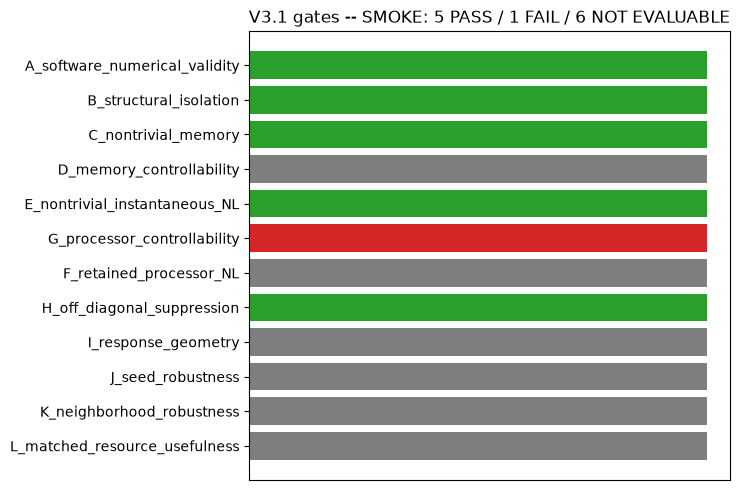

In [12]:
def gate(result, **extra):
    return {"result": result, **extra}

GATES = {}
GATES["A_software_numerical_validity"] = gate(
    "PASS" if TEST_REPORT["returncode"] == 0 else "FAIL",
    tests_passed=TEST_REPORT["passed"], tests_failed=TEST_REPORT["failed"])
GATES["B_structural_isolation"] = gate(
    "PASS" if CLAIM1_PASS else "FAIL",
    n_configs=len(iso_rows), worst_dXP_dm=worst,
    falsifiability_control_failed=not leak.passed)

if mem_rows:
    m_vals = [r["M_signed"] for r in mem_rows if r["accepted"]]
    GATES["C_nontrivial_memory"] = gate(
        "PASS" if (m_vals and float(np.median(m_vals)) > THRESHOLDS["min_memory"]) else "FAIL",
        median_M=(float(np.median(m_vals)) if m_vals else None))
else:
    GATES["C_nontrivial_memory"] = gate("NOT EVALUABLE", reason="discovery not executed")

GATES["D_memory_controllability"] = gate(
    "NOT EVALUABLE",
    reason="requires the confirmation-stage five-point stencil with hierarchical intervals")

if proc_rows:
    nl_vals = [r["NL0_signed"] for r in proc_rows if r["accepted"]]
    GATES["E_nontrivial_instantaneous_NL"] = gate(
        "PASS" if (nl_vals and float(np.median(nl_vals)) > THRESHOLDS["min_NL0"]) else "FAIL",
        median_NL0=(float(np.median(nl_vals)) if nl_vals else None))
    best_E = max((v["E"] for v in E_NL_by_variant.values() if np.isfinite(v["E"])), default=float("nan"))
    GATES["G_processor_controllability"] = gate(
        "PASS" if (np.isfinite(best_E) and best_E > THRESHOLDS["E_NL_min"]) else "FAIL",
        best_E_NL=best_E, threshold=THRESHOLDS["E_NL_min"],
        note="discovery-stage dynamic range; the confirmation gate additionally requires a "
             "resolved S_NL^P confidence interval")
else:
    GATES["E_nontrivial_instantaneous_NL"] = gate("NOT EVALUABLE", reason="discovery not executed")
    GATES["G_processor_controllability"] = gate("NOT EVALUABLE", reason="discovery not executed")

GATES["F_retained_processor_NL"] = gate("NOT EVALUABLE",
                                         reason="paired per-seed standalone matching runs in confirmation")
GATES["H_off_diagonal_suppression"] = gate(
    "PASS" if CLAIM1_PASS else "NOT EVALUABLE",
    note="off-diagonal sensitivity is an EXACT structural zero for the parallel routes; "
         "reported as an isolation bound rather than a ratio",
    upper_bound=worst)
GATES["I_response_geometry"] = gate("NOT EVALUABLE",
                                     reason="requires confirmation-stage derivatives")
GATES["J_seed_robustness"] = gate("NOT EVALUABLE", reason="held-out confirmation not executed")
GATES["K_neighborhood_robustness"] = gate("NOT EVALUABLE", reason="held-out confirmation not executed")
GATES["L_matched_resource_usefulness"] = gate("NOT EVALUABLE",
                                               reason="Pareto comparison runs in confirmation")

for k, v in GATES.items():
    print(f"{k:34s} {v['result']}")
n_pass = sum(1 for v in GATES.values() if v["result"] == "PASS")
n_fail = sum(1 for v in GATES.values() if v["result"] == "FAIL")
n_ne = sum(1 for v in GATES.values() if v["result"] == "NOT EVALUABLE")
print(f"\n{n_pass} PASS / {n_fail} FAIL / {n_ne} NOT EVALUABLE (of {len(GATES)})")
record("gates", GATES)
record("gate_summary", {"pass": n_pass, "fail": n_fail, "not_evaluable": n_ne, "total": len(GATES)})
dump(GATES, "gate_results.json")

fig, ax = plt.subplots(figsize=(7.5, 5))
cmap = {"PASS": "tab:green", "FAIL": "tab:red", "NOT EVALUABLE": "tab:gray"}
ax.barh(list(GATES), [1] * len(GATES), color=[cmap[v["result"]] for v in GATES.values()])
ax.set_xticks([]); ax.invert_yaxis()
ax.set_title(f"V3.1 gates -- {RUN_MODE}: {n_pass} PASS / {n_fail} FAIL / {n_ne} NOT EVALUABLE")
fig.tight_layout(); savefig(fig, "gate_chart", "gate_results.json", "per-gate verdict",
                            f"{CFG['n_reservoir']} reservoir x {CFG['n_input']} input seeds")
plt.show()

## 13. Conclusion

In [13]:
claims = {
    1: ("structural separation", CLAIM1_PASS),
    2: ("functional control separation", CONFIRMATION_EXECUTED and GATES["D_memory_controllability"]["result"] == "PASS"),
    3: ("matched-resource usefulness", GATES["L_matched_resource_usefulness"]["result"] == "PASS"),
}
ladder = {
    1: ("software-valid modular architecture", TEST_REPORT["returncode"] == 0),
    2: ("exact structural branch isolation", CLAIM1_PASS),
    3: ("nontrivial independent memory and nonlinear modules",
        GATES["C_nontrivial_memory"]["result"] == "PASS" and GATES["E_nontrivial_instantaneous_NL"]["result"] == "PASS"),
    4: ("robust functional control decoupling", claims[2][1]),
    5: ("matched-resource Pareto improvement", claims[3][1]),
}
supported = max([k for k, (_, ok) in ladder.items() if ok], default=0)

if RUN_MODE == "SMOKE":
    OUTCOME, RATIONALE = "I", (
        "SMOKE validates software only. Structural isolation, the ceiling repair, the "
        "ablation ladder and both module families are exercised end to end, but discovery "
        "and held-out confirmation remain unexecuted.")
elif not CLAIM1_PASS:
    OUTCOME, RATIONALE = "H", "structural isolation failed for the primary parallel architecture"
elif ENCODING_DOMINATES:
    OUTCOME, RATIONALE = "D", (
        f"encoding-only ablation reproduces {enc_frac:.0%} of the full instantaneous NL, so the "
        "classical input encoding -- not the (g,J) interaction -- supplies most of the nonlinearity")
elif GATES["G_processor_controllability"]["result"] == "FAIL":
    OUTCOME, RATIONALE = "B", "structurally separated, but NL(g,J) remains flat or unstable"
elif not CONFIRMATION_EXECUTED:
    OUTCOME, RATIONALE = "I", (
        "discovery selected and froze a candidate using discovery-only seeds; held-out "
        "confirmation remains unexecuted")
else:
    OUTCOME, RATIONALE = "I", "confirmation executed but the decisive gates were not all resolved"

print(f"OUTCOME {OUTCOME}\n{RATIONALE}\n")
for k, (desc, ok) in ladder.items():
    print(f"  Level {k}: {desc:48s} {'SUPPORTED' if ok else 'not supported'}")
print(f"\nHighest supported claim level: {supported}")
print(f"\nClaim 1 (structural): {'PASS' if claims[1][1] else 'not established'}")
print(f"Claim 2 (functional): {'PASS' if claims[2][1] else 'not established'}")
print(f"Claim 3 (usefulness): {'PASS' if claims[3][1] else 'not established'}")

if RUN_MODE == "SMOKE":
    print("\nThe V3.1 software framework and SMOKE execution were completed. Discovery and "
          "held-out confirmation remain unexecuted; no scientific decoupling claim is made.")
elif not CONFIRMATION_EXECUTED:
    print("\nDiscovery selected and froze a candidate using discovery-only seeds. Held-out "
          "confirmation remains unexecuted; the discovery result is not confirmatory evidence.")

record("conclusion", {"outcome": OUTCOME, "rationale": RATIONALE,
                       "claims": {str(k): {"name": v[0], "established": bool(v[1])} for k, v in claims.items()},
                       "claim_ladder": {str(k): {"description": d, "supported": bool(o)} for k, (d, o) in ladder.items()},
                       "highest_supported_level": supported})
if WF.state is not WorkflowState.REPORTED:
    WF.transition(WorkflowState.REPORTED)
record("workflow", WF.summary())

OUTCOME I
SMOKE validates software only. Structural isolation, the ceiling repair, the ablation ladder and both module families are exercised end to end, but discovery and held-out confirmation remain unexecuted.

  Level 1: software-valid modular architecture              SUPPORTED
  Level 2: exact structural branch isolation                SUPPORTED
  Level 3: nontrivial independent memory and nonlinear modules SUPPORTED
  Level 4: robust functional control decoupling             not supported
  Level 5: matched-resource Pareto improvement              not supported

Highest supported claim level: 3

Claim 1 (structural): PASS
Claim 2 (functional): not established
Claim 3 (usefulness): not established

The V3.1 software framework and SMOKE execution were completed. Discovery and held-out confirmation remain unexecuted; no scientific decoupling claim is made.


## 14. Save results, config and manifest

In [14]:
dump({"run_mode": RUN_MODE, "authorized": CONFIRM_EXPENSIVE_RUN, "config": CFG,
       "control_ranges": _RESULTS["control_ranges"], "thresholds": THRESHOLDS,
       "processor_variants": PROC_VARIANTS, "memory_variants": MEM_VARIANTS,
       "selected_max_degree": MAX_DEGREE, "environment": {**META, **ENV},
       "paths": PATHS.as_dict(), "cache_schema_version": CACHE_SCHEMA_VERSION,
       "frozen_config_sha256": (FROZEN.sha256 if FROZEN else None)},
     "validation_v3_1_config.json")
dump(_RESULTS, "validation_v3_1_results.json")
dump(_MANIFEST, "figure_manifest.json")
print("wrote validation_v3_1_config.json, validation_v3_1_results.json, gate_results.json,")
print("      discovery_results.csv, confirmation_results.csv, figure_manifest.json")
print(f"  -> {RESULTS_DIR}")
print(f"\n{len(_MANIFEST)} figures, {len(_RESULTS)} result blocks, workflow state {WF.state.value}")

wrote validation_v3_1_config.json, validation_v3_1_results.json, gate_results.json,
      discovery_results.csv, confirmation_results.csv, figure_manifest.json
  -> D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3_1

4 figures, 22 result blocks, workflow state REPORTED


## 15. Resume instructions

**Colab**: open from GitHub (branch `qiskit`, `code/DQRC_DualRoute_Decoupling_V3_1_Colab.ipynb`),
leave `USE_GOOGLE_DRIVE = True`, then `Runtime -> Run all`. CPU is sufficient; a GPU is
detected if present but never required and `qiskit-aer-gpu` is not assumed.

**To run discovery**:

```python
RUN_MODE = "DISCOVERY"
CONFIRM_EXPENSIVE_RUN = True
```

Discovery writes `frozen_config.json` with a SHA-256 hash. **To run confirmation**, keep
that file and set:

```python
RUN_MODE = "CONFIRMATION"
CONFIRM_EXPENSIVE_RUN = True
```

Confirmation verifies the frozen hash before doing any work and draws confirmation seeds
only. Checkpoints resume only when the full cache key matches; `FORCE_RECOMPUTE = True`
discards them.

**Locally**:

```bash
PYTHONPATH="code" python -m pytest tests/ -q
cd code && python _build_notebook_dualroute_v3_1_colab.py
jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=7200 DQRC_DualRoute_Decoupling_V3_1_Colab.ipynb
```